# FIRAS dark-photon limits: which statistic reproduces CCJ24

Figure 8 of the paper sets a 95% CL FIRAS upper limit on the dark-photon
kinetic mixing $\epsilon(m_{A'})$. It is about 15% stronger in $\epsilon$ than
the limit of [Chluba, Cyr & Johnson (2024)](https://arxiv.org/abs/2409.12115)
(CCJ24, Fig. 8). This notebook runs one set of `spectroxide` PDE templates
through five statistics and compares each result with the CCJ24 curve:

1. our reading of the CCJ24 statistic, with thresholds $\Delta\chi^2 = 2.71$,
   $3.84$, and $4$;
2. a goodness-of-fit (GoF) test with the full covariance and $\chi^2_{41}$;
3. the statistic of paper Fig. 8.

The CCJ24 curve is the author-supplied copy in the AxionLimits repository,
`dev/AxionLimits/limit_data/DarkPhoton/COBEFIRAS_Chluba.txt`.

**What CCJ24 say.** Their Sect. 5 describes the FIRAS analysis in one
paragraph. They ran 20,000 `CosmoTherm` models on a log–log grid,
$m_{A'}\in[10^{-12}, 10^{-3}]$ eV and $\epsilon\in[10^{-10}, 3\times10^{-5}]$.
For each model spectrum $\Delta\vec I$ they solve for the temperature-shift and
dust amplitudes $\Delta_T$, $\Delta_g$ with a diagonal noise covariance, form
$\Delta\vec S = \Delta\vec I - \Delta_T\vec G - \Delta_g\vec g$, and "compare the
obtained $\Delta S_i$ with distortion data from Fixsen (1996) using a simple
Gaussian likelihood". The paper does not state the threshold or the reference
point for $\chi^2$.

**Templates.** No PDE runs happen here. `dev/scripts/ccj24_gap/make_grid_templates.py`
ran the PDE at 30 masses from $1.5\times10^{-12}$ to $8\times10^{-5}$ eV, each at
$\epsilon$ equal to the CCJ24 curve, and saved the $G_{\rm bb}$-stripped
$\Delta n$ per unit $\gamma_{\rm con}$ to `grid_templates.npz`. At the limit
$\gamma_{\rm con}\sim10^{-4}$, so the template scales linearly with
$\gamma_{\rm con}\propto\epsilon^2$.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

from spectroxide import apply_style
from spectroxide.firas import FIRASData
from spectroxide.plot_params import C, DOUBLE_COL, LW, LW_THICK, LEGEND_SIZE

apply_style()
ROOT = Path.cwd().parent.parent
FIG_DIR = ROOT / 'notebooks' / 'figures'

# FIRAS monopole file (Fixsen et al. 1996): frequency [cm^-1], monopole [MJy/sr],
# residual [kJy/sr], 1-sigma error [kJy/sr], galaxy spectrum [kJy/sr]
f_cm, I_mono, RESID, SIGMA, GAL = np.loadtxt(ROOT / 'data/firas_monopole_spec_v1.txt').T
Q = np.loadtxt(ROOT / 'data/firas_correlation_matrix.txt')

H_PL, K_B, C_LIGHT = 6.62607015e-34, 1.380649e-23, 2.99792458e8   # SI, exact
T0 = 2.725                                                        # K
NU = f_cm * C_LIGHT * 100
X0 = H_PL * NU / (K_B * T0)
PREF = 2 * H_PL * NU**3 / C_LIGHT**2 / 1e-23         # kJy/sr per unit Delta n
G_T = PREF * X0 * np.exp(X0) / np.expm1(X0)**2       # temperature shift
N_NUIS = np.column_stack([G_T, GAL])                 # nuisance templates
CI_DIAG = np.diag(1 / SIGMA**2)
CI_FULL = np.linalg.inv(np.outer(SIGMA, SIGMA) * Q)
N_FREQ = len(NU)
CHI2_CRIT = chi2_dist.ppf(0.95, N_FREQ - 2)          # 56.94

# CCJ24 curve. Drop the file's contour-closure row at m ~ 1e-3 eV.
ref_ccj = np.loadtxt(ROOT / 'dev/AxionLimits/limit_data/DarkPhoton/COBEFIRAS_Chluba.txt')
ref_ccj = ref_ccj[ref_ccj[:, 0] <= 1.5e-4]


def eps_ccj(m):
    '''Log-log interpolation of the CCJ24 curve.'''
    return 10**np.interp(np.log10(m), np.log10(ref_ccj[:, 0]), np.log10(ref_ccj[:, 1]))


TMPL = np.load(ROOT / 'dev/scripts/ccj24_gap/grid_templates.npz', allow_pickle=True)
print(f"{len(TMPL['m'])} PDE templates, {TMPL['m'].min():.2e}-{TMPL['m'].max():.2e} eV; "
      f'chi2_41,0.95 = {CHI2_CRIT:.2f}')

30 PDE templates, 1.50e-12-8.00e-05 eV; chi2_41,0.95 = 56.94


## The statistics

The model is linear in the amplitude $a = \gamma_{\rm con} = (\gamma_{\rm con}/\epsilon^2)\,\epsilon^2$.
After the nuisance parameters are removed,
$\chi^2(a) = \chi^2_{\rm min} + (a - \hat a)^2/\sigma_a^2$, where $\hat a$ is the
unconstrained best fit. Write $k \equiv \hat a/\sigma_a$ and $a_{95} = u\,\sigma_a$.
FIRAS fluctuates low along the dark-photon shape, so $k < 0$ at every mass.

**(1) Our reading of CCJ24.** We follow their text literally: diagonal errors,
the Fixsen residual column as data, $T$ fixed at $T_0 = 2.725$ K, and
$\vec G$ and the Fixsen galaxy spectrum $\vec g$ projected out of the model only.
At each mass we evaluate $\chi^2$ on their $\epsilon$ grid (log-spaced,
$10^{-10}$ to $3\times10^{-5}$) and set the limit where
$\chi^2(\epsilon) - \min_{\rm grid}\chi^2 = t$. The grid contains only
$\epsilon \ge 0$, so for $k<0$ the minimum sits at the smallest $\epsilon$, which is
effectively no distortion. The limit is then
$u = k + \sqrt{k^2 + t}$. We test $t = 2.71$ (one-sided 95%), $3.84$ (two-sided
95%), and $4$ ($2\sigma$).

**(2) Goodness of fit.** For each $\epsilon$, fit the temperature shift and the
galaxy amplitude to data minus model with the full $43\times43$ covariance, and
reject the model when the absolute $\chi^2$ exceeds the 95th percentile of
$\chi^2_{41}$ (43 channels, 2 fitted nuisance parameters). This gives
$u = k + \sqrt{\chi^2_{41,0.95} - \chi^2_{\rm min}}$.

**(3) Paper Fig. 8.** `FIRASData.profile_limit_floating_T`: full covariance,
FIRAS monopole minus $B(\nu, T)$ as data, $T$ floated, $\nu^2B(\nu, 9\,{\rm K})$
dust, and $u = k + 1.645$ measured from the unconstrained best fit
($\hat a < 0$ allowed).

In [2]:
EPS_GRID = np.geomspace(1e-10, 3e-5, 40001)
FIRAS = FIRASData()


def remove_nuisance(v, Ci):
    '''v minus its generalized-least-squares fit to the nuisance templates.'''
    coef = np.linalg.solve(N_NUIS.T @ Ci @ N_NUIS, N_NUIS.T @ Ci @ v)
    return v - N_NUIS @ coef


def crossing(chi2, level):
    '''Smallest eps above the chi2 minimum where chi2 reaches level (log interpolation).'''
    i0 = int(np.argmin(chi2))
    above = np.nonzero(chi2[i0:] >= level)[0]
    if len(above) == 0 or chi2[i0] >= level:
        return np.nan
    j = i0 + above[0]
    return float(np.exp(np.interp(level, chi2[j - 1:j + 1], np.log(EPS_GRID[j - 1:j + 1]))))


def chi2_curves(tmpl, gpe2):
    '''chi2 on EPS_GRID for the CCJ24 reading (diagonal) and the GoF test (full cov).'''
    S = PREF * tmpl(X0)                         # per unit gamma_con
    a = gpe2 * EPS_GRID**2
    Sp = remove_nuisance(S, CI_DIAG)            # model-only projection
    r = RESID[None, :] - a[:, None] * Sp[None, :]
    chi2_ccj = np.einsum('ij,jk,ik->i', r, CI_DIAG, r)
    Sf, df = remove_nuisance(S, CI_FULL), remove_nuisance(RESID, CI_FULL)
    r = df[None, :] - a[:, None] * Sf[None, :]
    chi2_gof = np.einsum('ij,jk,ik->i', r, CI_FULL, r)
    k_ccj = (RESID @ CI_DIAG @ Sp) / np.sqrt(Sp @ CI_DIAG @ Sp)
    return chi2_ccj, chi2_gof, k_ccj


rows = []
for i, m in enumerate(TMPL['m']):
    tmpl = lambda x, _x=TMPL['x'][i], _d=TMPL['dn_per_gc'][i]: np.interp(x, _x, _d)
    gpe2 = float(TMPL['gpe2'][i])
    chi2_ccj, chi2_gof, k_ccj = chi2_curves(tmpl, gpe2)
    pl = FIRAS.profile_limit_floating_T(tmpl)
    row = {'m': m, 'ref': eps_ccj(m), 'gpe2': gpe2,
           'k_ccj': k_ccj, 'k_paper': pl['amplitude'] / pl['sigma'],
           'chi2min_gof': chi2_gof.min(),
           'gof': crossing(chi2_gof, CHI2_CRIT),
           'paper': np.sqrt(pl['upper_limit'] / gpe2)}
    for t in (2.71, 3.84, 4.0):
        row[f'dchi2_{t}'] = crossing(chi2_ccj, chi2_ccj.min() + t)
    rows.append(row)
res = pd.DataFrame(rows)

# Paper's linearity cut: gamma_con < 0.1 at the paper limit
res = res[res['gpe2'] * res['paper']**2 < 0.1].reset_index(drop=True)
print(f"{len(res)} masses after the gamma_con < 0.1 cut; "
      f"k (CCJ24 setup) = {res['k_ccj'].min():.2f} to {res['k_ccj'].max():.2f}; "
      f"k (paper setup) = {res['k_paper'].min():.2f} to {res['k_paper'].max():.2f}; "
      f"GoF chi2_min = {res['chi2min_gof'].min():.1f}")

30 masses after the gamma_con < 0.1 cut; k (CCJ24 setup) = -0.35 to -0.26; k (paper setup) = -0.47 to -0.39; GoF chi2_min = 48.7


### Check: the paper statistic

The paper column must reproduce the cached Fig. 8 curve
(`dev/data/dp_firas_pde_limits.npz`). That curve came from PDE runs with
$\epsilon_{\rm ref}$ iterated to the limit on an 80-mass grid, so small
differences come from the template amplitude and from interpolation.

In [3]:
cache = np.load(ROOT / 'dev' / 'data' / 'dp_firas_pde_limits.npz')
e_cache = 10**np.interp(np.log10(res['m']), np.log10(cache['m']), np.log10(cache['e_pl']))
r = res['paper'] / e_cache
print(f'paper statistic here / cached Fig. 8 curve: [{r.min():.3f}, {r.max():.3f}], '
      f'median {r.median():.3f}')

paper statistic here / cached Fig. 8 curve: [0.965, 1.007], median 1.000


## Results

Each limit divided by the CCJ24 curve.

In [4]:
STATS = [
    # key,         label,                                          style
    ('dchi2_2.71', r'CCJ24 reading, $\Delta\chi^2 = 2.71$',         dict(color=C['blue'], lw=LW, ls=':')),
    ('dchi2_3.84', r'CCJ24 reading, $\Delta\chi^2 = 3.84$',         dict(color=C['blue'], lw=LW_THICK, ls='-')),
    ('dchi2_4.0',  r'CCJ24 reading, $\Delta\chi^2 = 4$',            dict(color=C['teal'], lw=LW_THICK, ls='--')),
    ('gof',        r'GoF, full cov., $\chi^2_{41,0.95}$',           dict(color=C['gray'], lw=LW_THICK, ls='-')),
    ('paper',      r'paper Fig.~8 ($\hat a + 1.645\sigma$, floating $T$)', dict(color=C['red'], lw=LW_THICK, ls='-')),
]
summary = pd.DataFrame({
    key: {'median': (res[key] / res['ref']).median(),
          'min': (res[key] / res['ref']).min(),
          'max': (res[key] / res['ref']).max()}
    for key, _, _ in STATS}).T
summary.round(3)

,median,min,max
dchi2_2.71,0.887,0.848,0.906
dchi2_3.84,0.983,0.941,1.001
dchi2_4.0,0.995,0.952,1.012
gof,1.230,1.176,1.244
paper,0.849,0.812,0.876


In [5]:
table = res[['m']].copy()
for key, _, _ in STATS:
    table[key] = res[key] / res['ref']
table['k_ccj'], table['k_paper'] = res['k_ccj'], res['k_paper']
table.style.format({'m': '{:.2e}'} | {c: '{:.3f}' for c in table.columns if c != 'm'})

,m,dchi2_2.71,dchi2_3.84,dchi2_4.0,gof,paper,k_ccj,k_paper
0,1.50e-12,0.876,0.972,0.984,1.216,0.839,-0.348,-0.471
1,2.77e-12,0.873,0.968,0.980,1.211,0.836,-0.348,-0.471
2,5.12e-12,0.876,0.972,0.984,1.216,0.839,-0.348,-0.471
3,9.45e-12,0.881,0.977,0.989,1.222,0.843,-0.348,-0.471
4,1.75e-11,0.877,0.972,0.984,1.216,0.839,-0.348,-0.471
5,3.22e-11,0.869,0.964,0.975,1.205,0.832,-0.348,-0.471
6,5.95e-11,0.866,0.961,0.972,1.202,0.829,-0.348,-0.471
7,1.10e-10,0.866,0.960,0.972,1.201,0.829,-0.348,-0.471
8,2.03e-10,0.867,0.962,0.974,1.203,0.831,-0.348,-0.471
9,3.75e-10,0.871,0.967,0.978,1.209,0.835,-0.348,-0.471


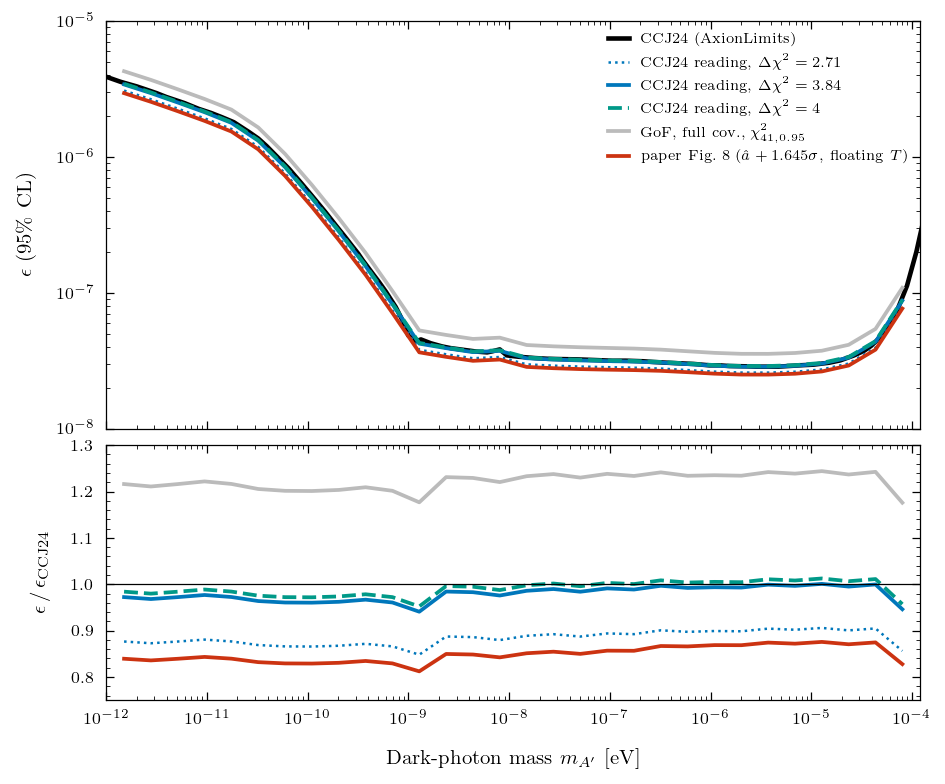

In [6]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(DOUBLE_COL, 6.0), sharex=True,
                              gridspec_kw={'height_ratios': [1.6, 1], 'hspace': 0.05})
m = res['m'].values
ax.loglog(ref_ccj[:, 0], ref_ccj[:, 1], color='k', lw=2.2, label='CCJ24 (AxionLimits)')
for key, lab, st in STATS:
    ax.loglog(m, res[key], **st, label=lab)
    axr.semilogx(m, res[key] / res['ref'], **st)
ax.set_ylabel(r'$\epsilon$ (95\% CL)')
ax.set_ylim(1e-8, 1e-5)
ax.legend(loc='upper right', fontsize=LEGEND_SIZE, framealpha=0.95)
axr.axhline(1, color='k', lw=0.6)
axr.set_ylim(0.75, 1.3)
axr.set_xlim(m.min() / 1.5, m.max() * 1.5)
axr.set_xlabel(r"Dark-photon mass $m_{A'}$ [eV]")
axr.set_ylabel(r'$\epsilon\,/\,\epsilon_{\rm CCJ24}$')
for ext in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'dp_firas_limit_conventions.{ext}', bbox_inches='tight', dpi=200)
plt.show()

## One mass in detail

At the template mass nearest $3\times10^{-8}$ eV we plot both $\chi^2$ curves
against $\epsilon$. Left: the CCJ24 reading, $\chi^2 - \min_{\rm grid}\chi^2$, with
the three thresholds. Right: the GoF test, absolute $\chi^2$, with
$\chi^2_{41,0.95}$. The vertical lines mark each limit and the CCJ24 curve.

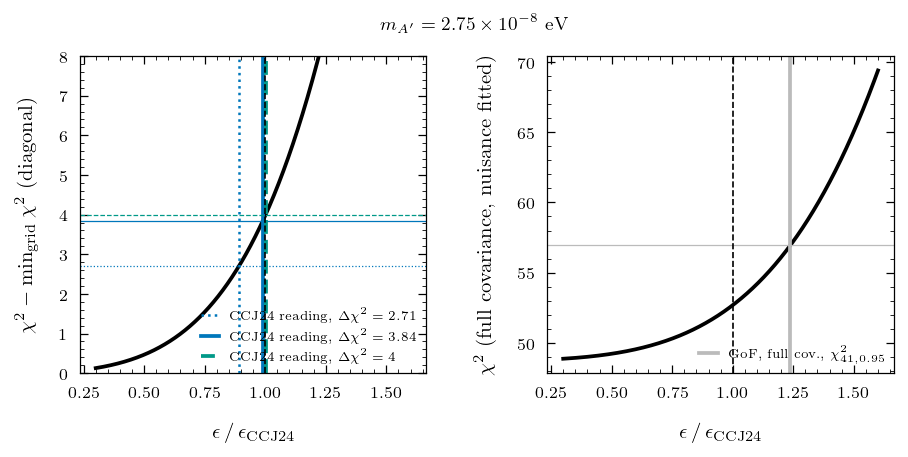

In [7]:
i = int(np.argmin(np.abs(np.log(TMPL['m'] / 3e-8))))
m1, gpe2 = float(TMPL['m'][i]), float(TMPL['gpe2'][i])
tmpl = lambda x, _x=TMPL['x'][i], _d=TMPL['dn_per_gc'][i]: np.interp(x, _x, _d)
chi2_ccj, chi2_gof, _ = chi2_curves(tmpl, gpe2)
e_ref = eps_ccj(m1)
sel = (EPS_GRID > 0.3 * e_ref) & (EPS_GRID < 1.6 * e_ref)
e = EPS_GRID[sel] / e_ref

fig, (a1, a2) = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.8), sharex=True,
                         gridspec_kw={'wspace': 0.35})
a1.plot(e, chi2_ccj[sel] - chi2_ccj.min(), color='k', lw=LW_THICK)
for key, lab, st in STATS[:3]:
    t = float(key.split('_')[1])
    a1.axhline(t, color=st['color'], lw=0.6, ls=st['ls'])
    a1.axvline(crossing(chi2_ccj, chi2_ccj.min() + t) / e_ref, **st, label=lab)
a1.set_ylim(0, 8)
a1.set_ylabel(r'$\chi^2 - \min_{\rm grid}\chi^2$ (diagonal)')
a1.legend(fontsize=LEGEND_SIZE - 1, loc='lower right', framealpha=0.95)

a2.plot(e, chi2_gof[sel], color='k', lw=LW_THICK)
a2.axhline(CHI2_CRIT, color=C['gray'], lw=0.6)
a2.axvline(crossing(chi2_gof, CHI2_CRIT) / e_ref, **STATS[3][2], label=STATS[3][1])
a2.set_ylabel(r'$\chi^2$ (full covariance, nuisance fitted)')
a2.legend(fontsize=LEGEND_SIZE - 1, loc='lower right', framealpha=0.95)
for ax_ in (a1, a2):
    ax_.axvline(1, color='k', lw=0.8, ls='--')
    ax_.set_xlabel(r'$\epsilon\,/\,\epsilon_{\rm CCJ24}$')
mant, expo = f'{m1:.2e}'.split('e')
fig.suptitle(rf"$m_{{A'}} = {mant}\times10^{{{int(expo)}}}$ eV", fontsize=LEGEND_SIZE + 2)
for ext in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'dp_firas_limit_conventions_dchi2.{ext}', bbox_inches='tight', dpi=200)
plt.show()

## Conclusions

**Our reading of CCJ24 reproduces their curve with $\Delta\chi^2 = 3.84$ or $4$.**
Measured from the grid minimum, which is the no-distortion model because
$k<0$, the two thresholds give 0.983 and 0.995 of the CCJ24 curve (medians).
From $2\times10^{-9}$ to $4\times10^{-5}$ eV, $\Delta\chi^2 = 4$ stays within 1.2% of
the curve and $3.84$ within 2%. Below $10^{-9}$ eV both run 2–4% low. The
remaining data cannot separate 3.84 from 4.

**$\Delta\chi^2 = 2.71$ does not fit.** It gives 0.887 of the curve, 11% too
tight.

**Two dips come from the templates, not the statistics.** At
$1.3\times10^{-9}$ eV (recombination) and $8\times10^{-5}$ eV every curve drops
by the same factor. The cause is the difference between our template and
`CosmoTherm`'s, or the steepness of the curve there.

**The GoF test does not reproduce CCJ24.** With the full covariance,
$\chi^2_{\rm min} = 48.7$, so the limit sits
$\sqrt{56.94 - 48.7} \approx 2.9\,\sigma_a$ above $\hat a$, against
$\sqrt{t} \approx 2\,\sigma_a$ above the no-distortion model for the CCJ24
reading. The result is 1.23 of the CCJ24 curve. A GoF test spends its 5% on 41
directions and only one of them is the signal, so it is not an upper-limit
method.

**The paper statistic is 15% stronger than CCJ24** (median 0.849). It uses a
threshold of 2.71 measured from the unconstrained best fit, which has
$\hat a < 0$, and it uses the full covariance, the monopole column, and a
floating $T$. The $\Delta\chi^2 = 2.71$ row differs from it only in these
inputs and in measuring the threshold from the no-distortion model, and it
lands about 4% higher. Most of the gap to CCJ24 is therefore the step from
$\Delta\chi^2 = 3.84$–$4$ against the no-distortion model to $2.71$ against a
negative best fit.